# PINN for 1D viscous Burgers' equation (shock-ish regime)

We solve the 1D viscous Burgers' equation on a space–time slab:
$$
u_t + u\,u_x - \nu u_{xx} = 0,\qquad (x,t)\in[-1,1]\times[0,1].
$$

We impose:
- **Initial condition** (IC):
$$
u(x,0) = -\sin(\pi x).
$$
- **Dirichlet boundary conditions** (BC):
$$
u(-1,t)=u(1,t)=0.
$$

We train a physics-informed neural network $u_\theta(x,t)$ by minimizing:
$$
\mathcal L(\theta)=
\underbrace{\mathbb E_{(x,t)\sim\Omega}\big[r_\theta(x,t)^2\big]}_{\text{PDE residual}}
+\lambda_{ic}\underbrace{\mathbb E_{x\sim[-1,1]}\big[(u_\theta(x,0)-u_0(x))^2\big]}_{\text{IC}}
+\lambda_{bc}\underbrace{\mathbb E_{t\sim[0,1]}\big[u_\theta(-1,t)^2+u_\theta(1,t)^2\big]}_{\text{BC}},
$$
where the residual is
$$
r_\theta(x,t)=u_{\theta,t}+u_\theta\,u_{\theta,x}-\nu u_{\theta,xx}.
$$

**Notes.**
- When $\nu$ is small, the solution develops sharp gradients (shock-like behavior), which makes optimization nontrivial.
- We'll use Adam, with simple resampling of collocation points. Optionally, you can run L-BFGS afterward.


In [18]:
import numpy as np
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt

# Reproducibility
seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. Problem setup and helper functions
We choose a viscosity $\nu$ small enough to produce sharp gradients but not so small that training becomes extremely brittle.


In [15]:
# Domain bounds
x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, 1.0

# Viscosity (try 0.01 or 0.005 for stronger shock-like behavior)
nu = 0.01

def u0(x):
    "Initial condition u(x,0) = -sin(pi x)"
    return -torch.sin(np.pi * x)

def sample_interior(n):
    "Uniform samples in the interior (x,t) ~ [-1,1]x[0,1]"
    x = torch.rand(n, 1, device=device) * (x_max - x_min) + x_min
    t = torch.rand(n, 1, device=device) * (t_max - t_min) + t_min
    return x, t

def sample_ic(n):
    "Samples on initial line t=0"
    x = torch.rand(n, 1, device=device) * (x_max - x_min) + x_min
    t = torch.zeros(n, 1, device=device)
    return x, t

def sample_bc(n):
    "Samples on boundaries x=-1 and x=1"
    t = torch.rand(n, 1, device=device) * (t_max - t_min) + t_min
    xL = torch.full((n, 1), x_min, device=device)
    xR = torch.full((n, 1), x_max, device=device)
    return xL, t, xR, t


## 2. A small MLP for $u_\theta(x,t)$
We use a standard fully-connected network with $\tanh$ activations. You can increase width/depth if needed.


In [16]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, width=64, depth=4):
        super().__init__()
        layers = []
        layers.append(nn.Linear(in_dim, width))
        layers.append(nn.Tanh())
        for _ in range(depth-1):
            layers.append(nn.Linear(width, width))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(width, out_dim))
        self.net = nn.Sequential(*layers)

        # Xavier init helps for tanh
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

model = MLP(width=64, depth=4).to(device)
sum(p.numel() for p in model.parameters())


12737

## 3. Autodiff: computing $u_t$, $u_x$, $u_{xx}$ and the PDE residual
This is the core PINN “construction” step. We use PyTorch autograd twice to get the second derivative.


In [ ]:
def gradients(y, x):
    # dy/dx for batched tensors
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), create_graph=True, retain_graph=True
    )[0]

def pde_residual_burgers(model, x, t, nu):
    # Ensure x,t track gradients
    x = x.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    u = model(x, t)
    u_t = gradients(u, t)
    u_x = gradients(u, x)
    u_xx = gradients(u_x, x)

    r = u_t + u * u_x - nu * u_xx
    return r, u


## 4. Training loop (Adam)
We resample collocation points every step. This is often enough for a clean educational notebook.

You can tune:
- number of interior points $N_f$
- number of IC points $N_{ic}$
- number of BC points $N_{bc}$
- weights $\lambda_{ic},\lambda_{bc}$


In [ ]:
# Training hyperparameters
N_f  = 20000   # interior collocation points per iteration
N_ic = 2000    # IC points
N_bc = 2000    # BC points

lambda_ic = 10.0
lambda_bc = 10.0

lr = 1e-3
iters = 4000   # increase for better quality (e.g., 8000)

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

def step():
    model.train()
    optimizer.zero_grad()

    # Interior residual
    x_f, t_f = sample_interior(N_f)
    r_f, _ = pde_residual_burgers(model, x_f, t_f, nu)
    loss_f = torch.mean(r_f**2)

    # Initial condition
    x_ic, t_ic = sample_ic(N_ic)
    u_ic_pred = model(x_ic, t_ic)
    loss_ic = torch.mean((u_ic_pred - u0(x_ic))**2)

    # Boundary conditions
    xL, tL, xR, tR = sample_bc(N_bc)
    uL = model(xL, tL)
    uR = model(xR, tR)
    loss_bc = torch.mean(uL**2) + torch.mean(uR**2)

    loss = loss_f + lambda_ic * loss_ic + lambda_bc * loss_bc
    loss.backward()
    optimizer.step()

    return loss.item(), loss_f.item(), loss_ic.item(), loss_bc.item()

history = {"loss":[], "loss_f":[], "loss_ic":[], "loss_bc":[]}

t0 = time.time()
for k in range(1, iters+1):
    L, Lf, Lic, Lbc = step()
    history["loss"].append(L)
    history["loss_f"].append(Lf)
    history["loss_ic"].append(Lic)
    history["loss_bc"].append(Lbc)
    if k % 200 == 0 or k == 1:
        print(f"iter {k:5d} | loss {L: .3e} | pde {Lf: .3e} | ic {Lic: .3e} | bc {Lbc: .3e}")
print("Done in", round(time.time()-t0, 2), "sec")


iter     1 | loss  7.448e+00 | pde  5.799e-02 | ic  6.481e-01 | bc  9.092e-02
iter   200 | loss  4.453e-01 | pde  2.370e-01 | ic  1.754e-02 | bc  3.285e-03
iter   400 | loss  3.746e-01 | pde  2.417e-01 | ic  1.154e-02 | bc  1.748e-03
iter   600 | loss  3.241e-01 | pde  2.532e-01 | ic  5.558e-03 | bc  1.533e-03
iter   800 | loss  2.873e-01 | pde  2.099e-01 | ic  6.737e-03 | bc  1.003e-03
iter  1000 | loss  2.209e-01 | pde  1.788e-01 | ic  3.703e-03 | bc  4.989e-04
iter  1200 | loss  1.790e-01 | pde  1.509e-01 | ic  2.525e-03 | bc  2.841e-04
iter  1400 | loss  1.427e-01 | pde  1.198e-01 | ic  1.917e-03 | bc  3.665e-04
iter  1600 | loss  9.245e-02 | pde  7.584e-02 | ic  1.441e-03 | bc  2.207e-04
iter  1800 | loss  5.834e-02 | pde  4.395e-02 | ic  1.157e-03 | bc  2.818e-04
iter  2000 | loss  4.201e-02 | pde  3.189e-02 | ic  5.215e-04 | bc  4.901e-04
iter  2200 | loss  3.301e-02 | pde  2.297e-02 | ic  3.109e-04 | bc  6.933e-04
iter  2400 | loss  2.051e-02 | pde  1.455e-02 | ic  3.705e-04 | 

## 5. Diagnostics: loss curves


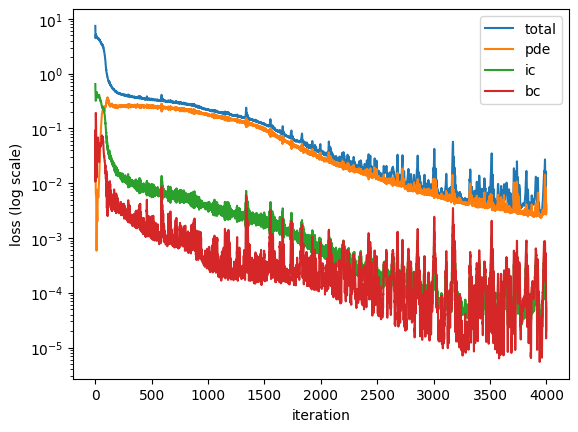

In [10]:
plt.figure()
plt.semilogy(history["loss"], label="total")
plt.semilogy(history["loss_f"], label="pde")
plt.semilogy(history["loss_ic"], label="ic")
plt.semilogy(history["loss_bc"], label="bc")
plt.xlabel("iteration")
plt.ylabel("loss (log scale)")
plt.legend()
plt.show()


## 6. Visualizing the learned solution $u_\theta(x,t)$
We evaluate on a grid and plot $u(x,t)$ as a heatmap plus a few time slices.

**Remark.** We are not comparing to a reference numerical solver here (to keep the notebook minimal).
If you want, we can add a finite-difference reference solution in a later iteration.


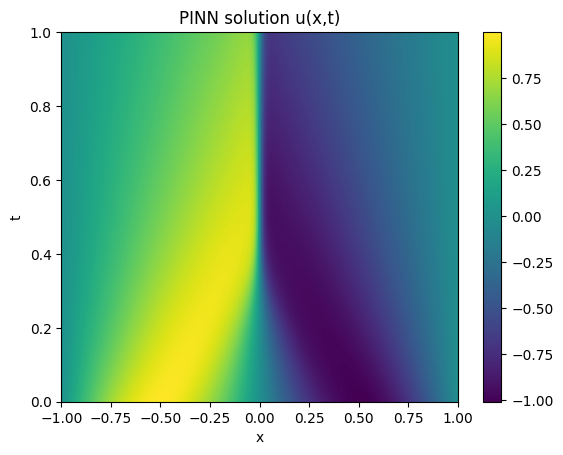

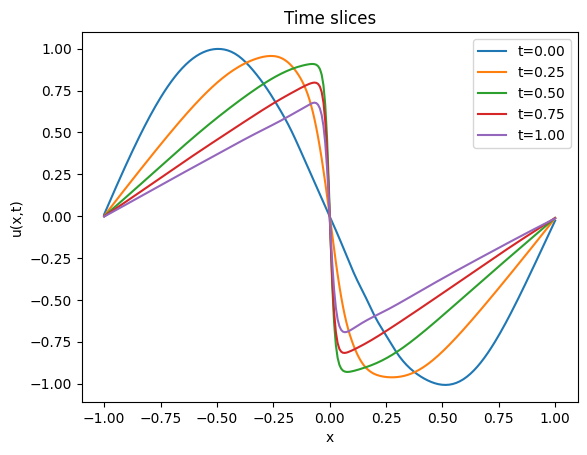

In [11]:
@torch.no_grad()
def eval_on_grid(model, nx=256, nt=101):
    xs = torch.linspace(x_min, x_max, nx, device=device).view(-1,1)
    ts = torch.linspace(t_min, t_max, nt, device=device).view(-1,1)
    X, T = torch.meshgrid(xs.squeeze(1), ts.squeeze(1), indexing="ij")
    xg = X.reshape(-1,1)
    tg = T.reshape(-1,1)
    ug = model(xg, tg).reshape(nx, nt).cpu().numpy()
    return xs.cpu().numpy().squeeze(), ts.cpu().numpy().squeeze(), ug

xg, tg, ug = eval_on_grid(model)

plt.figure()
plt.imshow(ug.T, aspect="auto", origin="lower",
           extent=[x_min, x_max, t_min, t_max])
plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN solution u(x,t)")
plt.colorbar()
plt.show()

# Plot a few time slices
plt.figure()
for t_query in [0.0, 0.25, 0.5, 0.75, 1.0]:
    j = int(round(t_query*(len(tg)-1)))
    plt.plot(xg, ug[:, j], label=f"t={tg[j]:.2f}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Time slices")
plt.legend()
plt.show()


## 6.5 Reference solution (finite differences) and error vs PINN

To demonstrate that the PINN is actually approximating the \emph{true} PDE solution (and not merely driving the training loss down), we compute a **numerical reference solution** $u_{\mathrm{ref}}$ on a grid using a simple finite-difference scheme, and compare $u_\theta$ to it.

We use the conservative form
$$
u_t + \partial_x\!\left(\tfrac12 u^2\right) = \nu u_{xx},
$$
with Dirichlet BC and the given IC.

**Stability note.** The explicit scheme requires a small time step; we choose $\Delta t$ via a conservative CFL-like rule.


In [12]:
import numpy as np

def burgers_fd_reference(nu, nx=512, nt=2000):
    # Finite-difference reference solver for viscous Burgers on x in [-1,1], t in [0,1]
    # BC: u(-1,t)=u(1,t)=0, IC: u(x,0)=-sin(pi x)
    #
    # Scheme: Rusanov (local Lax-Friedrichs) flux for advection + explicit diffusion.
    x = np.linspace(x_min, x_max, nx)
    dx = x[1] - x[0]
    t = np.linspace(t_min, t_max, nt)
    dt = t[1] - t[0]

    u = -np.sin(np.pi * x)
    u[0] = 0.0
    u[-1] = 0.0

    U = np.zeros((nx, nt), dtype=np.float64)
    U[:, 0] = u

    def flux(u):
        return 0.5 * u**2

    for n in range(nt - 1):
        f = flux(u)
        a = np.maximum(np.abs(u[:-1]), np.abs(u[1:]))          # local wave speed
        F = 0.5*(f[:-1] + f[1:]) - 0.5*a*(u[1:] - u[:-1])     # interface fluxes, size nx-1

        u_new = u.copy()
        u_new[1:-1] = u[1:-1] - (dt/dx) * (F[1:] - F[:-1])    # conservative advection
        u_xx = (u[2:] - 2*u[1:-1] + u[:-2]) / (dx*dx)
        u_new[1:-1] += nu * dt * u_xx                          # diffusion

        u_new[0] = 0.0
        u_new[-1] = 0.0

        u = u_new
        U[:, n+1] = u

    return x, t, U

# Choose nt via a conservative CFL-like rule
nx_ref = 512
x_tmp = np.linspace(x_min, x_max, nx_ref)
dx_tmp = x_tmp[1] - x_tmp[0]
max_u_guess = 1.0
dt_adv  = 0.4 * dx_tmp / max_u_guess
dt_diff = 0.4 * dx_tmp*dx_tmp / nu
dt = min(dt_adv, dt_diff)
nt_ref = int(np.ceil((t_max - t_min)/dt)) + 1
nt_ref = max(nt_ref, 800)
print("Reference grid:", nx_ref, "x-points,", nt_ref, "t-points (dt≈", (t_max-t_min)/(nt_ref-1), ")")

x_ref, t_ref, U_ref = burgers_fd_reference(nu, nx=nx_ref, nt=nt_ref)


Reference grid: 512 x-points, 1634 t-points (dt≈ 0.000612369871402327 )


Relative L2 error over the full grid: 0.013578861406767562
RMSE over the full grid: 0.008114825457784995


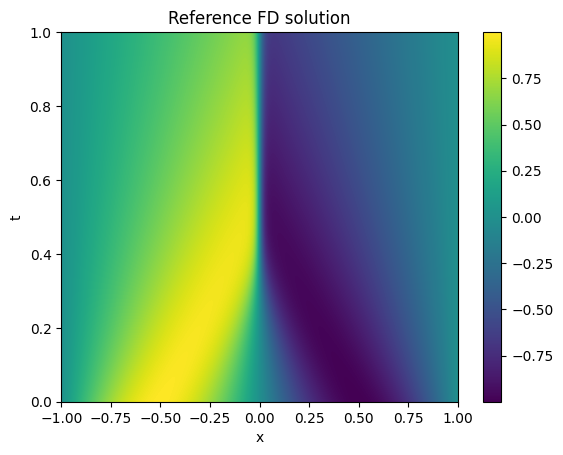

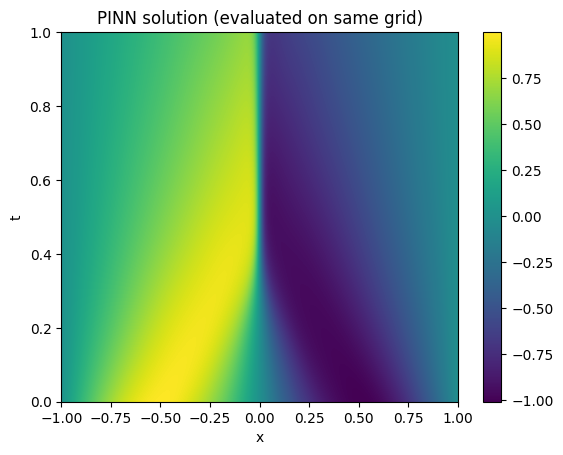

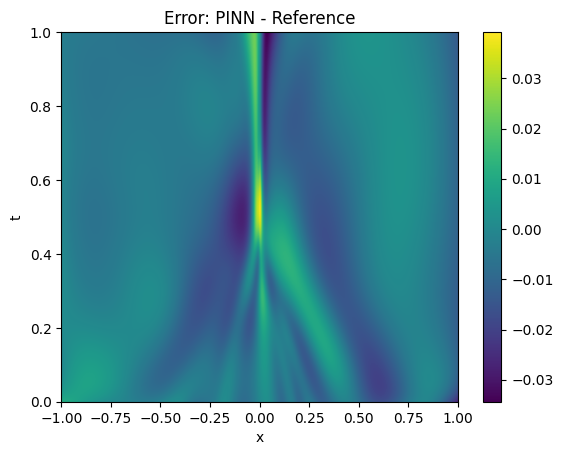

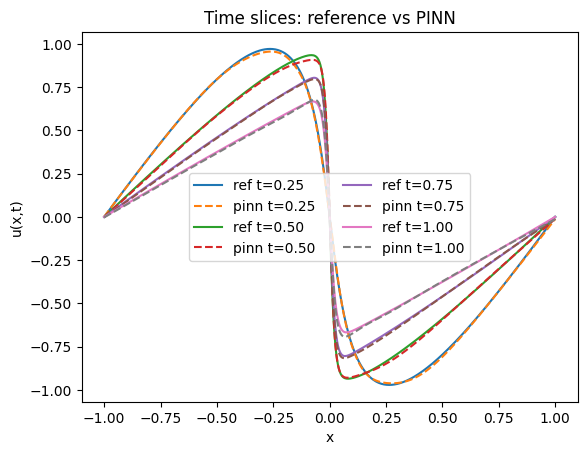

In [9]:
import torch

@torch.no_grad()
def eval_pinn_on_grid(model, x, t):
    xs = torch.tensor(x, device=device, dtype=torch.float32).view(-1,1)
    ts = torch.tensor(t, device=device, dtype=torch.float32).view(-1,1)
    X, T = torch.meshgrid(xs.squeeze(1), ts.squeeze(1), indexing="ij")
    U = model(X.reshape(-1,1), T.reshape(-1,1)).reshape(len(x), len(t)).cpu().numpy()
    return U

U_pinn = eval_pinn_on_grid(model, x_ref, t_ref)

err = U_pinn - U_ref
rel_L2 = np.linalg.norm(err) / np.linalg.norm(U_ref)
rmse  = np.sqrt(np.mean(err**2))

print("Relative L2 error over the full grid:", rel_L2)
print("RMSE over the full grid:", rmse)

# Heatmaps
plt.figure()
plt.imshow(U_ref.T, aspect="auto", origin="lower", extent=[x_min, x_max, t_min, t_max])
plt.xlabel("x"); plt.ylabel("t"); plt.title("Reference FD solution")
plt.colorbar(); plt.show()

plt.figure()
plt.imshow(U_pinn.T, aspect="auto", origin="lower", extent=[x_min, x_max, t_min, t_max])
plt.xlabel("x"); plt.ylabel("t"); plt.title("PINN solution (evaluated on same grid)")
plt.colorbar(); plt.show()

plt.figure()
plt.imshow(err.T, aspect="auto", origin="lower", extent=[x_min, x_max, t_min, t_max])
plt.xlabel("x"); plt.ylabel("t"); plt.title("Error: PINN - Reference")
plt.colorbar(); plt.show()

# Time slices
plt.figure()
for t_query in [0.25, 0.5, 0.75, 1.0]:
    j = int(np.argmin(np.abs(t_ref - t_query)))
    plt.plot(x_ref, U_ref[:, j], label=f"ref t={t_ref[j]:.2f}")
    plt.plot(x_ref, U_pinn[:, j], "--", label=f"pinn t={t_ref[j]:.2f}")
plt.xlabel("x"); plt.ylabel("u(x,t)")
plt.title("Time slices: reference vs PINN")
plt.legend(ncol=2)
plt.show()


# Inverse PINN demo: 2D Darcy flow with unknown permeability

We now demonstrate a setting where PINNs show their *full power*: **inverse problems**.

We consider the 2D Darcy flow PDE on $\Omega=[0,1]^2$:
$$
-\nabla\cdot\big(k(x,y)\nabla u(x,y)\big)=f(x,y).
$$

We assume we know:
- the forcing $f(x,y)$,
- boundary conditions (here: $u=0$ on $\partial\Omega$),
- a small number of noisy measurements $u(x_m,y_m)$ at $M$ sensor points.

We want to recover:
- the full solution field $u(x,y)$,
- the unknown coefficient field $k(x,y)>0$ (permeability).

**PINN parameterization.**
We train two neural nets:
- $u_\theta(x,y)$ for the solution,
- $s_\phi(x,y)$ for log-permeability, with $k_\phi(x,y)=\exp(s_\phi(x,y))$ to ensure positivity.

**Loss.**
Let
$$
r_{\theta,\phi}(x,y) = -\nabla\cdot\big(k_\phi\nabla u_\theta\big) - f(x,y).
$$
We minimize
$$
\mathcal L(\theta,\phi)=
\mathbb E_{\Omega}\big[r_{\theta,\phi}(x,y)^2\big]
+\lambda_b\,\mathbb E_{\partial\Omega}\big[u_\theta(x,y)^2\big]
+\lambda_d\,\frac1M\sum_{m=1}^M\big(u_\theta(x_m,y_m)-u_m^{\mathrm{obs}}\big)^2.
$$

We use a **manufactured ground truth** $(u^\star,k^\star)$ to generate synthetic data and evaluate accuracy.

In [20]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Reproducibility
seed = 1
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## 1. Manufactured ground truth: $u^\star(x,y)$, $k^\star(x,y)$, and $f(x,y)$

We pick smooth fields so we can compute $f(x,y)=-\nabla\cdot(k^\star\nabla u^\star)$ via autodiff.

We also impose $u^\star=0$ on $\partial\Omega$ by choosing a factor $x(1-x)y(1-y)$.

In [39]:
# Domain: [0,1]^2
x_min, x_max = 0.0, 1.0
y_min, y_max = 0.0, 1.0

def u_star_torch(x, y):
    # still zero on boundary, but smoother / lower frequency
    return (x*(1-x)*y*(1-y)) * (torch.sin(np.pi*x) * torch.sin(np.pi*y))

def logk_star_torch(x, y):
    # MUCH easier: small-amplitude, smooth variation around 0
    return 0.2 * torch.sin(np.pi*x) * torch.sin(np.pi*y)

def k_star_torch(x, y):
    return torch.exp(logk_star_torch(x, y))

def grads(y, x):
    return torch.autograd.grad(y, x, grad_outputs=torch.ones_like(y),
                               create_graph=True, retain_graph=True)[0]

def f_star_torch(x, y):
    # f = -div(k grad u) computed by autodiff
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    u = u_star_torch(x, y)
    k = k_star_torch(x, y)

    u_x = grads(u, x)
    u_y = grads(u, y)

    kux = k * u_x
    kuy = k * u_y

    div = grads(kux, x) + grads(kuy, y)
    f = -div
    return f.detach()

In [40]:
def sample_interior(n):
    x = torch.rand(n, 1, device=device) * (x_max - x_min) + x_min
    y = torch.rand(n, 1, device=device) * (y_max - y_min) + y_min
    return x, y

def sample_boundary(n):
    # Sample points on the boundary of the square
    # Half on vertical edges, half on horizontal edges
    n2 = n // 2

    # x=0 or x=1
    y1 = torch.rand(n2, 1, device=device)
    x1 = torch.cat([torch.zeros(n2//2,1,device=device), torch.ones(n2 - n2//2,1,device=device)], dim=0)
    y1 = y1[torch.randperm(n2)]

    # y=0 or y=1
    x2 = torch.rand(n - n2, 1, device=device)
    y2 = torch.cat([torch.zeros((n-n2)//2,1,device=device), torch.ones((n-n2) - (n-n2)//2,1,device=device)], dim=0)
    x2 = x2[torch.randperm(n - n2)]

    x = torch.cat([x1, x2], dim=0)
    y = torch.cat([y1, y2], dim=0)
    return x, y

def make_sensors(M, noise_std=0.01):
    xs = torch.rand(M, 1, device=device) * (x_max - x_min) + x_min
    ys = torch.rand(M, 1, device=device) * (y_max - y_min) + y_min
    with torch.no_grad():
        u_clean = u_star_torch(xs, ys)
        u_obs = u_clean + noise_std * torch.randn_like(u_clean)
    return xs, ys, u_obs

## 3. Models: $u_\theta(x,y)$ and $k_\phi(x,y)=\exp(s_\phi(x,y))$

We use MLPs with $\tanh$ activations.

In [41]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, width=1024, depth=3):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth-1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, out_dim)]
        self.net = nn.Sequential(*layers)

        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

u_net = MLP(width=64, depth=4).to(device)       # u_theta
s_net = MLP(width=64, depth=4).to(device)       # s_phi (log k)

def k_net(x, y):
    return torch.exp(s_net(x, y))               # enforce positivity

In [42]:
def pde_residual(u_net, s_net, x, y):
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)

    u = u_net(x, y)
    k = torch.exp(s_net(x, y))

    u_x = grads(u, x)
    u_y = grads(u, y)

    kux = k * u_x
    kuy = k * u_y

    div = grads(kux, x) + grads(kuy, y)

    f = f_star_torch(x, y).to(device)
    r = -div - f
    return r, u, k

In [43]:
# Hyperparameters
N_f  = 20000   # interior collocation points per iteration
N_b  = 4000    # boundary points per iteration
M    = 200     # number of sensors

noise_std = 0.01
xs, ys, u_obs = make_sensors(M, noise_std=noise_std)

lambda_b = 50.0
lambda_d = 50.0

params = list(u_net.parameters()) + list(s_net.parameters())
opt = torch.optim.Adam(params, lr=1e-3)

def train_step():
    opt.zero_grad()

    # Interior PDE residual
    x_f, y_f = sample_interior(N_f)
    r, _, _ = pde_residual(u_net, s_net, x_f, y_f)
    loss_f = torch.mean(r**2)

    # Boundary loss: u=0 on boundary
    x_b, y_b = sample_boundary(N_b)
    u_b = u_net(x_b, y_b)
    loss_b = torch.mean(u_b**2)

    # Data loss at sensors
    u_pred = u_net(xs, ys)
    loss_d = torch.mean((u_pred - u_obs)**2)

    loss = loss_f + lambda_b * loss_b + lambda_d * loss_d
    loss.backward()
    opt.step()
    return loss.item(), loss_f.item(), loss_b.item(), loss_d.item()

hist = {"loss":[], "f":[], "b":[], "d":[]}

iters = 5000
for it in range(1, iters+1):
    L, Lf, Lb, Ld = train_step()
    hist["loss"].append(L); hist["f"].append(Lf); hist["b"].append(Lb); hist["d"].append(Ld)
    if it % 250 == 0 or it == 1:
        print(f"iter {it:5d} | loss {L: .3e} | pde {Lf: .3e} | bc {Lb: .3e} | data {Ld: .3e}")

iter     1 | loss  1.285e+01 | pde  1.010e+00 | bc  1.303e-01 | data  1.064e-01
iter   250 | loss  1.016e+00 | pde  9.878e-01 | bc  7.092e-05 | data  5.018e-04
iter   500 | loss  1.019e+00 | pde  9.918e-01 | bc  5.671e-05 | data  4.828e-04
iter   750 | loss  1.020e+00 | pde  9.946e-01 | bc  4.983e-05 | data  4.621e-04
iter  1000 | loss  1.007e+00 | pde  9.829e-01 | bc  4.561e-05 | data  4.437e-04
iter  1250 | loss  1.020e+00 | pde  9.964e-01 | bc  4.192e-05 | data  4.254e-04
iter  1500 | loss  1.005e+00 | pde  9.830e-01 | bc  4.150e-05 | data  4.023e-04
iter  1750 | loss  9.938e-01 | pde  9.733e-01 | bc  3.861e-05 | data  3.712e-04
iter  2000 | loss  9.748e-01 | pde  9.571e-01 | bc  3.576e-05 | data  3.194e-04
iter  2250 | loss  2.857e-01 | pde  2.296e-01 | bc  5.390e-04 | data  5.847e-04
iter  2500 | loss  4.400e-02 | pde  1.990e-02 | bc  3.309e-05 | data  4.488e-04
iter  2750 | loss  3.500e-02 | pde  1.075e-02 | bc  7.428e-05 | data  4.107e-04
iter  3000 | loss  3.302e-02 | pde  8.85

KeyboardInterrupt: 

## 6. Evaluation and plots: recovered $u$ and $k$

We compare against the ground truth fields on a grid:
- $u_\theta$ vs $u^\star$
- $k_\phi$ vs $k^\star$ (or compare $\log k$ to avoid scale issues)

Relative L2 error u: 0.8007967
Relative L2 error log k: 19.574978


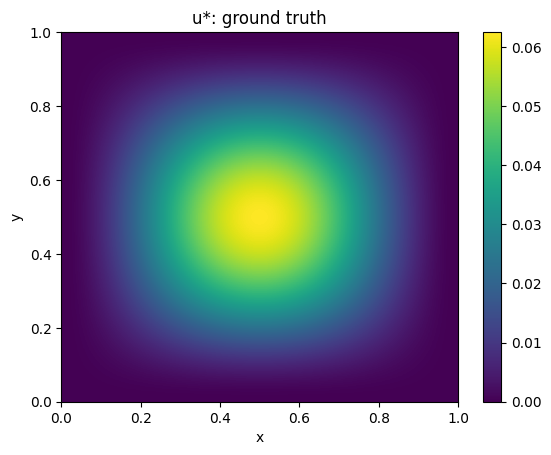

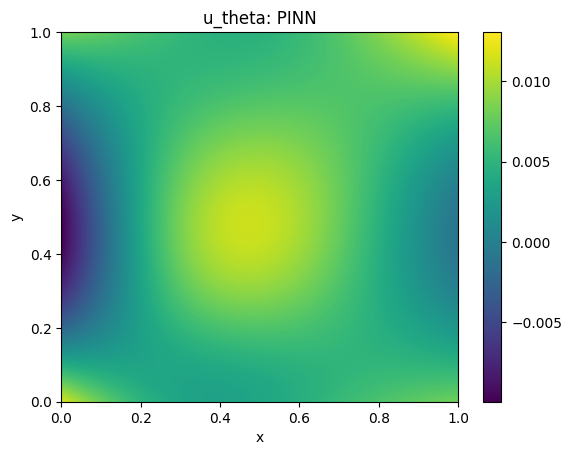

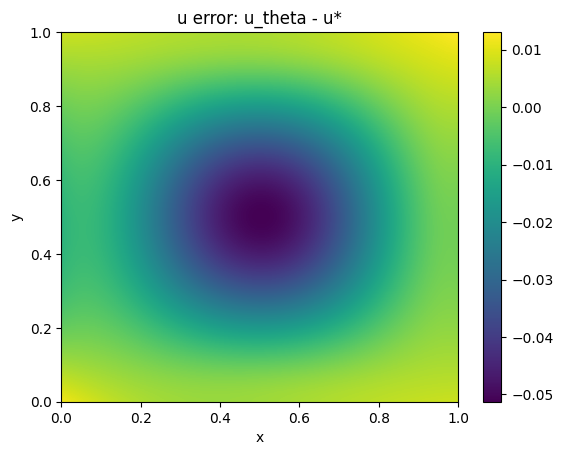

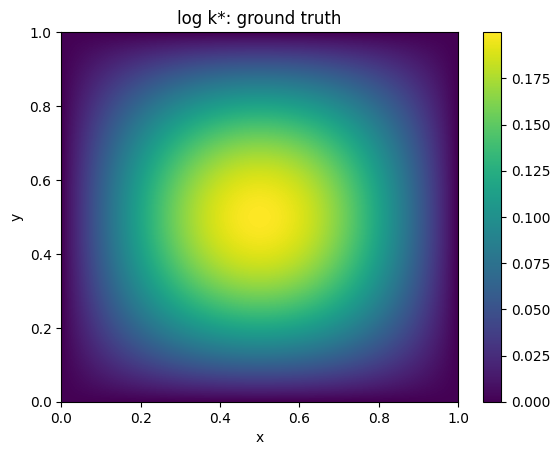

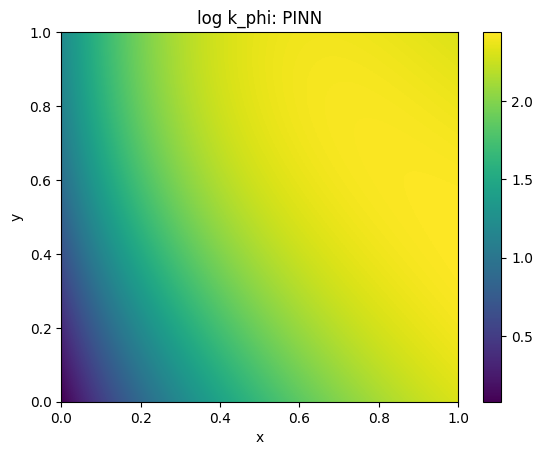

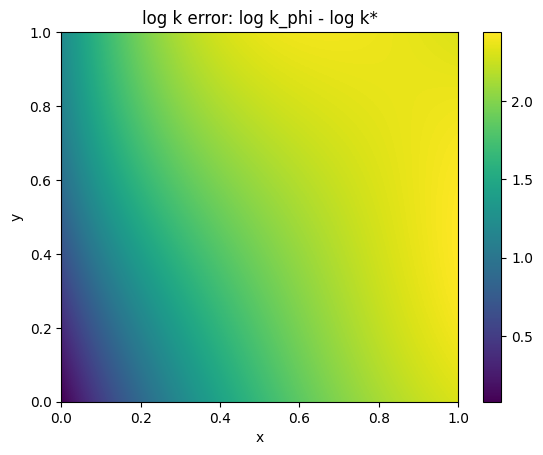

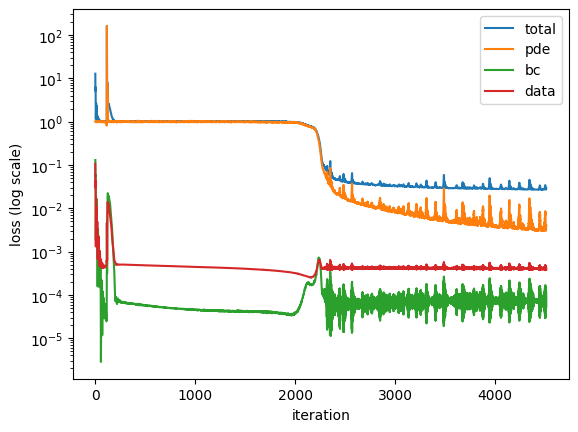

In [44]:
@torch.no_grad()
def eval_on_grid(u_net, s_net, n=200):
    x = torch.linspace(0,1,n,device=device).view(-1,1)
    y = torch.linspace(0,1,n,device=device).view(-1,1)
    X, Y = torch.meshgrid(x.squeeze(1), y.squeeze(1), indexing="ij")
    xx = X.reshape(-1,1); yy = Y.reshape(-1,1)

    u_pred = u_net(xx, yy).reshape(n,n).cpu().numpy()
    logk_pred = s_net(xx, yy).reshape(n,n).cpu().numpy()

    # truth
    u_true = u_star_torch(xx, yy).reshape(n,n).cpu().numpy()
    logk_true = logk_star_torch(xx, yy).reshape(n,n).cpu().numpy()
    return u_pred, u_true, logk_pred, logk_true

u_pred, u_true, logk_pred, logk_true = eval_on_grid(u_net, s_net, n=200)

def rel_l2(a, b):
    return np.linalg.norm(a-b) / np.linalg.norm(b)

print("Relative L2 error u:", rel_l2(u_pred, u_true))
print("Relative L2 error log k:", rel_l2(logk_pred, logk_true))

# Plot u
plt.figure()
plt.imshow(u_true.T, origin="lower", extent=[0,1,0,1], aspect="auto")
plt.title("u*: ground truth")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(); plt.show()

plt.figure()
plt.imshow(u_pred.T, origin="lower", extent=[0,1,0,1], aspect="auto")
plt.title("u_theta: PINN")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(); plt.show()

plt.figure()
plt.imshow((u_pred - u_true).T, origin="lower", extent=[0,1,0,1], aspect="auto")
plt.title("u error: u_theta - u*")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(); plt.show()

# Plot log k (more stable than k directly)
plt.figure()
plt.imshow(logk_true.T, origin="lower", extent=[0,1,0,1], aspect="auto")
plt.title("log k*: ground truth")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(); plt.show()

plt.figure()
plt.imshow(logk_pred.T, origin="lower", extent=[0,1,0,1], aspect="auto")
plt.title("log k_phi: PINN")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(); plt.show()

plt.figure()
plt.imshow((logk_pred - logk_true).T, origin="lower", extent=[0,1,0,1], aspect="auto")
plt.title("log k error: log k_phi - log k*")
plt.xlabel("x"); plt.ylabel("y")
plt.colorbar(); plt.show()

# Loss curves
plt.figure()
plt.semilogy(hist["loss"], label="total")
plt.semilogy(hist["f"], label="pde")
plt.semilogy(hist["b"], label="bc")
plt.semilogy(hist["d"], label="data")
plt.xlabel("iteration")
plt.ylabel("loss (log scale)")
plt.legend()
plt.show()